# Sintel Optical Flow Dataset

In this notebook, we apply the `circle_bundles` pipeline to confirm and expand upon the 2-manifold model proposed by Adams et al. for high-contrast optical flow patches sampled from the MPI-Sintel dataset. The model is homeomorphic to a torus, but the topology cannot be satisfactorily detected from a direct persistence computation.

## Quick and publication-scale runs

The `quick` profile uses the tutorial-scale sample $X(300,50)$ and is useful for running through the entire notebook in a fresh environment. The `paper` profile uses the full $X(1500,50)$ sample from the manuscript. Change `profile` in the next cell (or set `OPTICAL_FLOW_PROFILE`) to switch between them. The mathematical analysis below is identical in both cases.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import circle_bundles as cb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from persim import plot_diagrams
from ripser import ripser

ROOT = Path.cwd().resolve()
if not (ROOT / "data").is_dir() and (ROOT.parent / "data").is_dir():
    ROOT = ROOT.parent

profile = Path(os.environ.get("OPTICAL_FLOW_PROFILE", "quick")).stem
random_seed = 0    

if profile == "quick":
    patches_per_frame = 400
    raw_sample_cap = 400000
    max_samples = 50000
    k_list = [300]
    k = 300
    p = 0.5
    n_landmarks = 16
    overlap = 1.99
    artifact_name = "preprocessed_quick.v1.npz"
elif profile == "paper":
    patches_per_frame = 4000
    raw_sample_cap = None
    max_samples = 250000
    k_list = [10, 50, 100, 200, 300, 1500]
    k = 1500
    p = 0.5
    n_landmarks = 16
    overlap = 1.5
    artifact_name = "HC20_Flow_Patches.v1.npz"
else:
    raise ValueError("profile must be either 'quick' or 'paper'")

print(f"Running the {profile} profile.")

Running the quick profile.


The MPI Sintel dataset is provided by the Max Planck Institute for Informatics and is subject to its original license terms. The following cell loads a portable preprocessed sample when one is available. Otherwise, it reproduces the original sampling and preprocessing steps from the raw Sintel flow frames.

In [2]:
artifact_path = Path(
    os.environ.get("OPTICAL_FLOW_PREPROCESSED", ROOT / "data" / artifact_name)
).expanduser()

if artifact_path.is_file():
    #Load the portable, pickle-free version of the preprocessed patch table
    with np.load(artifact_path, allow_pickle=False) as archive:
        metadata = json.loads(str(archive["metadata_json"].item()))
        columns = {
            name: np.asarray(archive[metadata["key_map"][name]])
            for name in metadata["scalar_columns"]
        }
        patches = np.asarray(archive["patches"])

    patch_df = pd.DataFrame(columns)
    patch_df.insert(0, "patch", list(patches))
    data_source = "portable preprocessed artifact"
    print(f"{len(patch_df):,} preprocessed optical flow patches loaded")
else:
    folder_path = os.environ.get(
        "MPI_SINTEL_FLOW_DIR",
        ".../MPI-Sintel-complete/training/flow",
    )    #change to your path to the Sintel flow frames
    if not Path(folder_path).expanduser().is_dir():
        raise RuntimeError(
            f"No portable artifact was found at {artifact_path}. Set "
            "MPI_SINTEL_FLOW_DIR to MPI-Sintel-complete/training/flow."
        )

    patch_df, file_paths = cb.get_patch_sample(
        folder_path,
        patches_per_frame=patches_per_frame,
        d=3,
        random_state=random_seed,
    )
    print(f"{len(patch_df):,} optical flow patches sampled")

    #Downsample if necessary
    if raw_sample_cap is not None and len(patch_df) > raw_sample_cap:
        patch_df = patch_df.sample(n=raw_sample_cap, random_state=random_seed)

    #Keep the top 20 percent by contrast norm and compute KNN densities
    patch_df = cb.preprocess_flow_patches(
        patch_df,
        hc_frac=0.2,
        max_samples=max_samples,
        k_list=k_list,
        random_state=random_seed,
    )
    data_source = "raw MPI-Sintel flow frames"

50,000 preprocessed optical flow patches loaded


Finally, keep only the top $100p$ percent of patches by the density value $1/\rho_k(x)$. The quick profile produces the tutorial-scale set $X(300,50)$, while the publication profile produces $X(1500,50)$.

In [3]:
density_column = f"density_{k}"
patch_df = patch_df.sort_values(
    density_column,
    ascending=False,
    kind="mergesort",
).reset_index(drop=True)

n_samples = int(p*len(patch_df))
data = np.vstack(patch_df["patch"])[:n_samples]
print(f"X({k}, {int(100*p)}) contains {len(data):,} patches")

X(300, 50) contains 25,000 patches


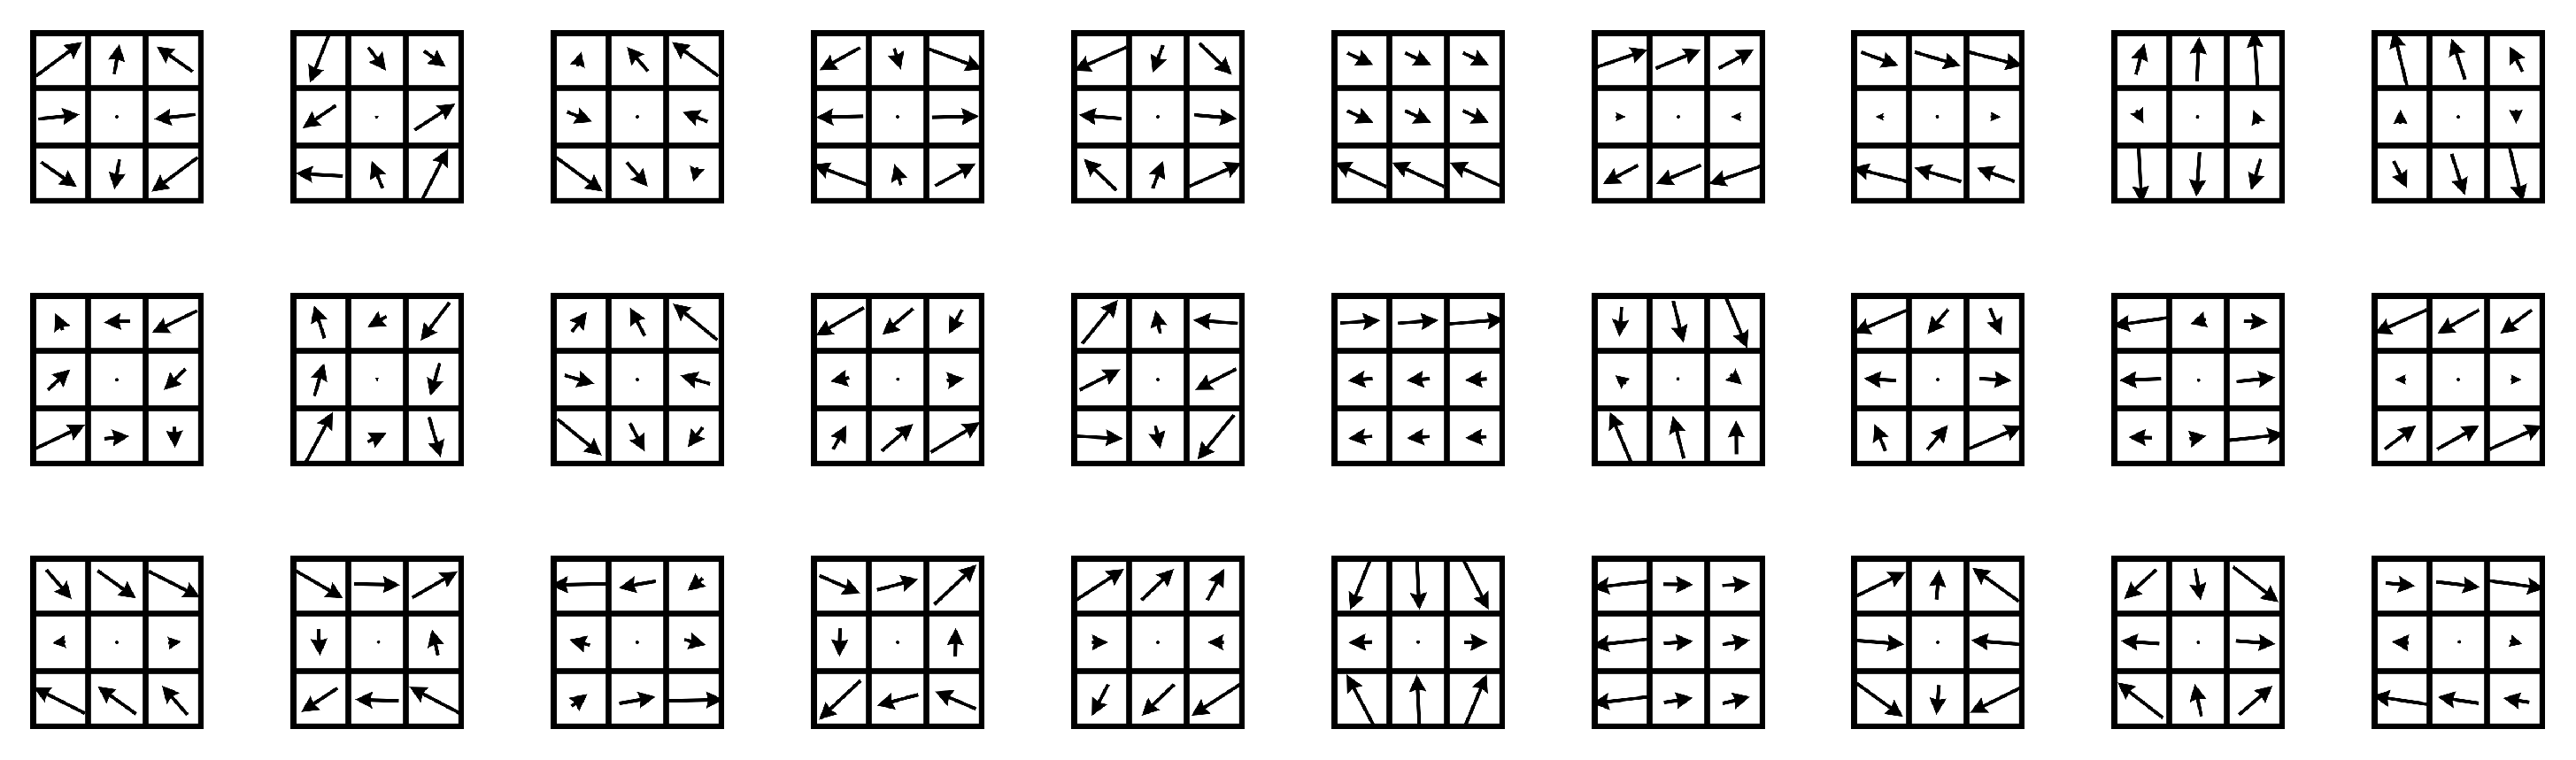

In [4]:
patch_vis = cb.make_patch_visualizer()
fig = cb.show_data_vis(
    data,
    patch_vis,
    sampling_method=None,
    max_samples=30,
)
plt.show()

## Preliminary Analysis

Compare direct persistence for the two dense-core subsets used in the paper with persistence for samples from the idealized optical-flow torus at several noise levels. The paper profile reconstructs Figure 6 with 500 Ripser landmarks. The quick profile runs the same six-panel comparison with 250 landmarks. The two real-data panels reproduce the recovered diagrams exactly. The historical synthetic seed and final noise-normalization convention were not recorded, so the synthetic panels use the explicit deterministic convention below.

In [ ]:
global_ripser_points = 500 if profile == "paper" else 250

#Compare X(k,50) and X(k,30). Ripser's greedy permutation is the
#500-point subsampling used by the recovered analysis.
real_panels = [(f"X({k},0.5)", data)]
n_samples_30 = int(0.3*len(patch_df))
data_30 = np.vstack(patch_df["patch"])[:n_samples_30]
real_panels.append((f"X({k},0.3)", data_30))

global_rips = {}
for title, dataset in real_panels:
    print(f"Computing persistence for {title} from {len(dataset):,} patches")
    global_rips[title] = ripser(
        dataset,
        maxdim=2,
        n_perm=global_ripser_points,
    )["dgms"]

#Compare with the idealized torus at the noise levels shown in Figure 6.
#The historical seed and final noise normalization were not recorded; this
#public run uses the current Circle Bundles contrast-renormalized convention.
#Reinitializing the generator holds the clean sample and noise directions fixed,
#so sigma alone changes across these four panels.
synthetic_noise_levels = (0.05, 0.1, 0.2, 0.3)
for sigma in synthetic_noise_levels:
    synthetic_rng = np.random.default_rng(random_seed)
    synthetic_data, _, _ = cb.sample_opt_flow_torus(
        global_ripser_points,
        dim=3,
        sigma=sigma,
        rng=synthetic_rng,
        sample_r=False,
        contrast_renorm=True,
        return_r=False,
    )
    title = rf"$\sigma = {sigma}$"
    global_rips[title] = ripser(synthetic_data, maxdim=2)["dgms"]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
for ax, (title, panel_diagrams) in zip(axes.flat, global_rips.items()):
    plot_diagrams(panel_diagrams, ax=ax, show=False)
    ax.set_title(title)

plt.tight_layout()
figure_dir = ROOT / "results" / profile / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
global_ripsers_name = "Global_Ripsers.pdf" if profile == "paper" else "Global_Ripsers_quick.pdf"
global_ripsers_path = figure_dir / global_ripsers_name
fig.savefig(global_ripsers_path, bbox_inches="tight")
plt.show()
print(f"Saved {global_ripsers_path}")

#Keep the main X(k,50) diagrams available under the original variable name.
diagrams = global_rips[real_panels[0][0]]

Neither real dense-core subset has the Betti signature of a torus: two persistent classes in dimension 1 and one in dimension 2. The low-noise synthetic samples do show that signature, while increasing noise gradually obscures it. This mismatch motivates the local-to-global bundle analysis below.

## Bundle Analysis

Proceed with local-to-global analysis. Compute the predominant flow axis in $\mathbb{RP}^{1}$ and directionality for each patch, and construct a cover of $\mathbb{RP}^{1}$.

In [7]:
predom_dirs, ratios = cb.get_predominant_dirs(data)

#Construct a cover of the base space
landmarks = np.linspace(0, np.pi, n_landmarks, endpoint=False).reshape(-1, 1)
radius = overlap*np.pi/(2*n_landmarks)

cover = cb.get_metric_ball_cover(
    predom_dirs.reshape(-1, 1),
    landmarks,
    radius=radius,
    metric=cb.RP1AngleMetric(),
)

bundle = cb.Bundle(X=data, U=cover.U)

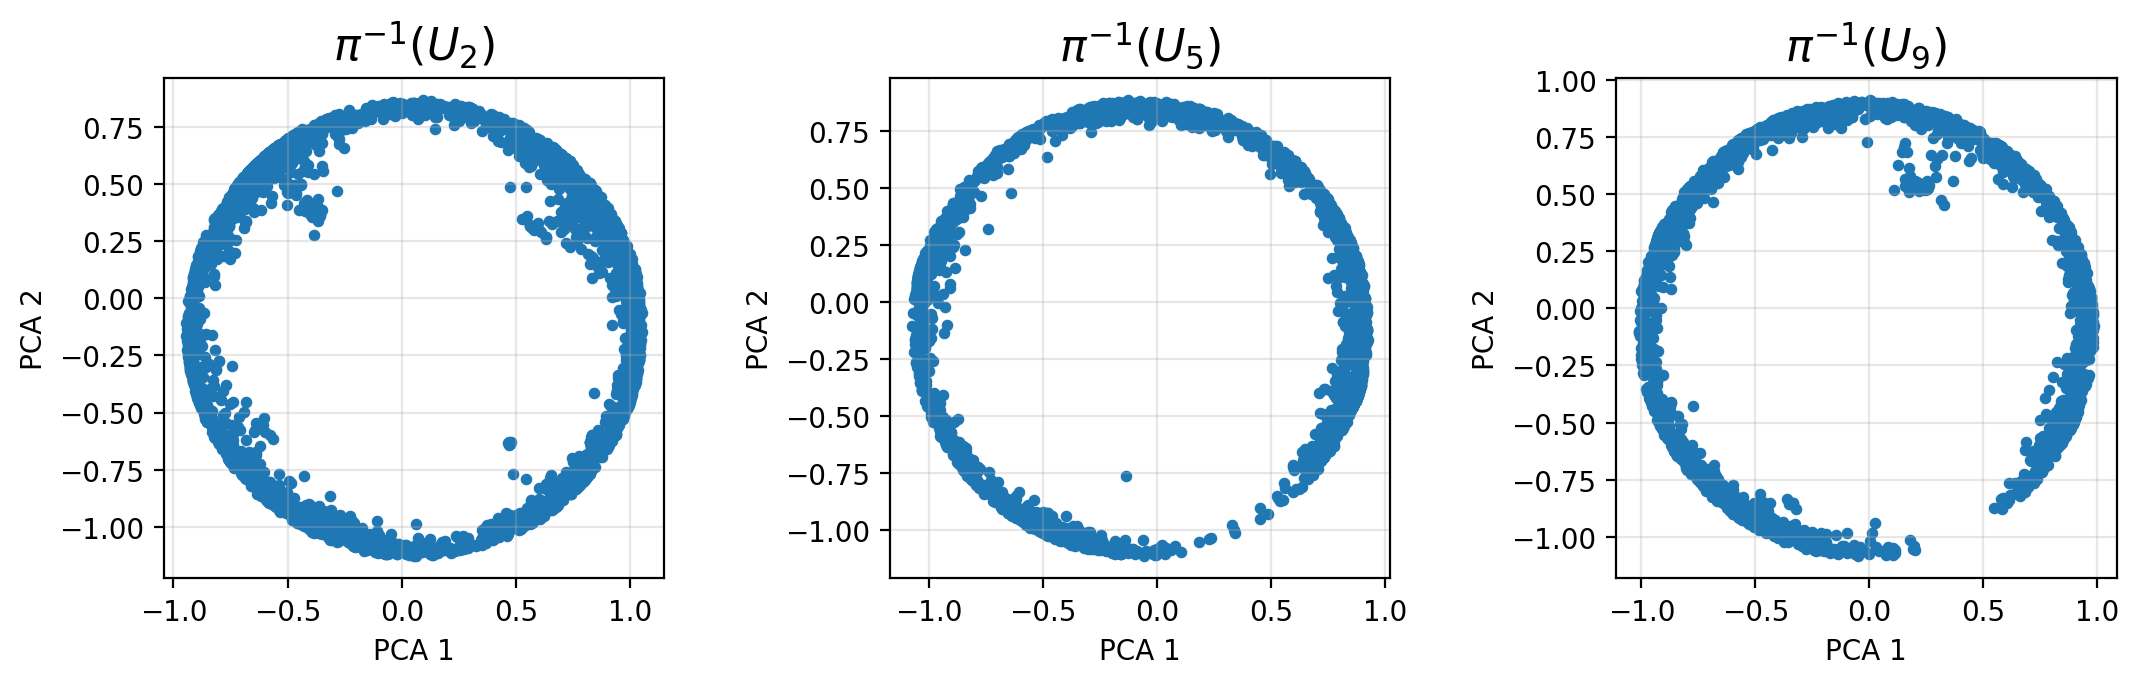

In [8]:
#Compute a PCA projection for the data in several sets pi^{-1}(U_j)
to_view = [2, 5, 9]
fig, axes = cb.get_local_pca(
    data=data,
    U=cover.U,
    show=True,
    to_view=to_view,
)

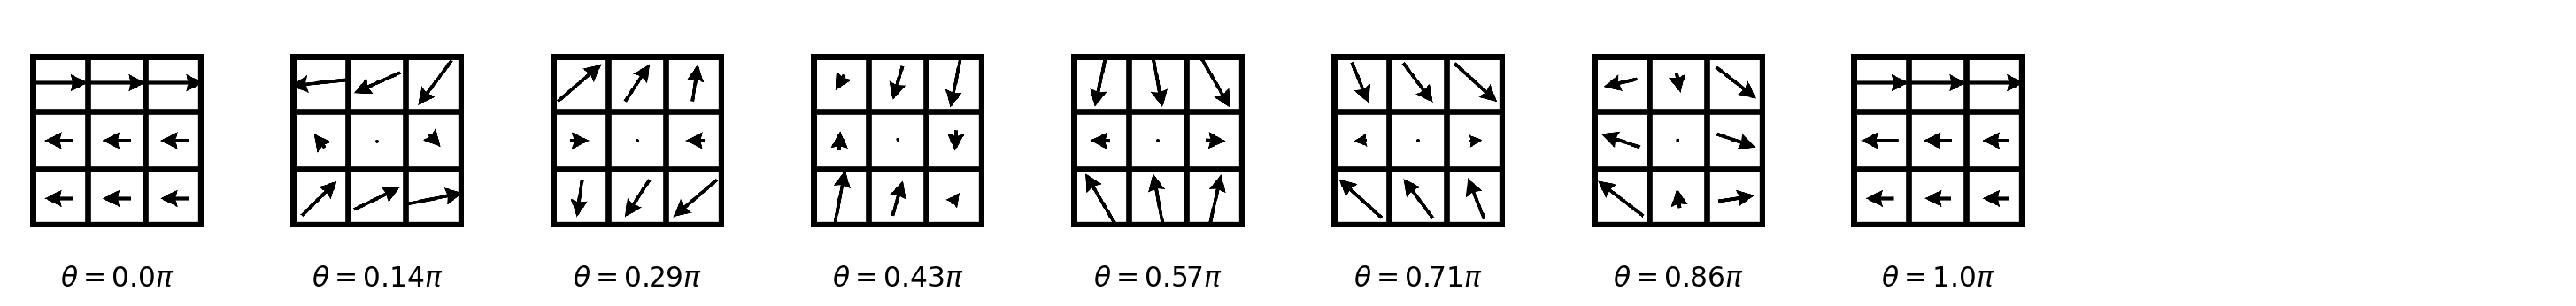

In [9]:
n_samples = 8
label_func = [
    fr"$\theta = {np.round(pred/np.pi, 2)}$" + r"$\pi$"
    for pred in predom_dirs
]
fig = cb.show_data_vis(
    data,
    patch_vis,
    label_func=label_func,
    angles=predom_dirs,
    sampling_method="angle",
    max_samples=n_samples,
)
plt.show()

The PCA projections suggest the data in each $\pi^{-1}(U_j)$ is concentrated near the unit circle in some plane, supporting the hypothesis that the data has the structure of a discrete approximate circle bundle over $\mathbb{RP}^{1}$. Up to isomorphism, there are two possible global structures: the torus and the Klein bottle. These possibilities are distinguished by the orientation class $w_1$.

Construct local circular coordinates, compute approximate transition matrices and characteristic classes, and synchronize the local coordinates to construct a global toroidal coordinate system.

In [10]:
local_triv_result = bundle.get_local_trivs(show_summary=True)
class_result = bundle.get_classes(show_classes=True)
fiber_angles = bundle.get_global_trivialization(pou=cover.pou)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

View a sample of high-directionality patches arranged by toroidal coordinates:

15,877 high-directionality patches


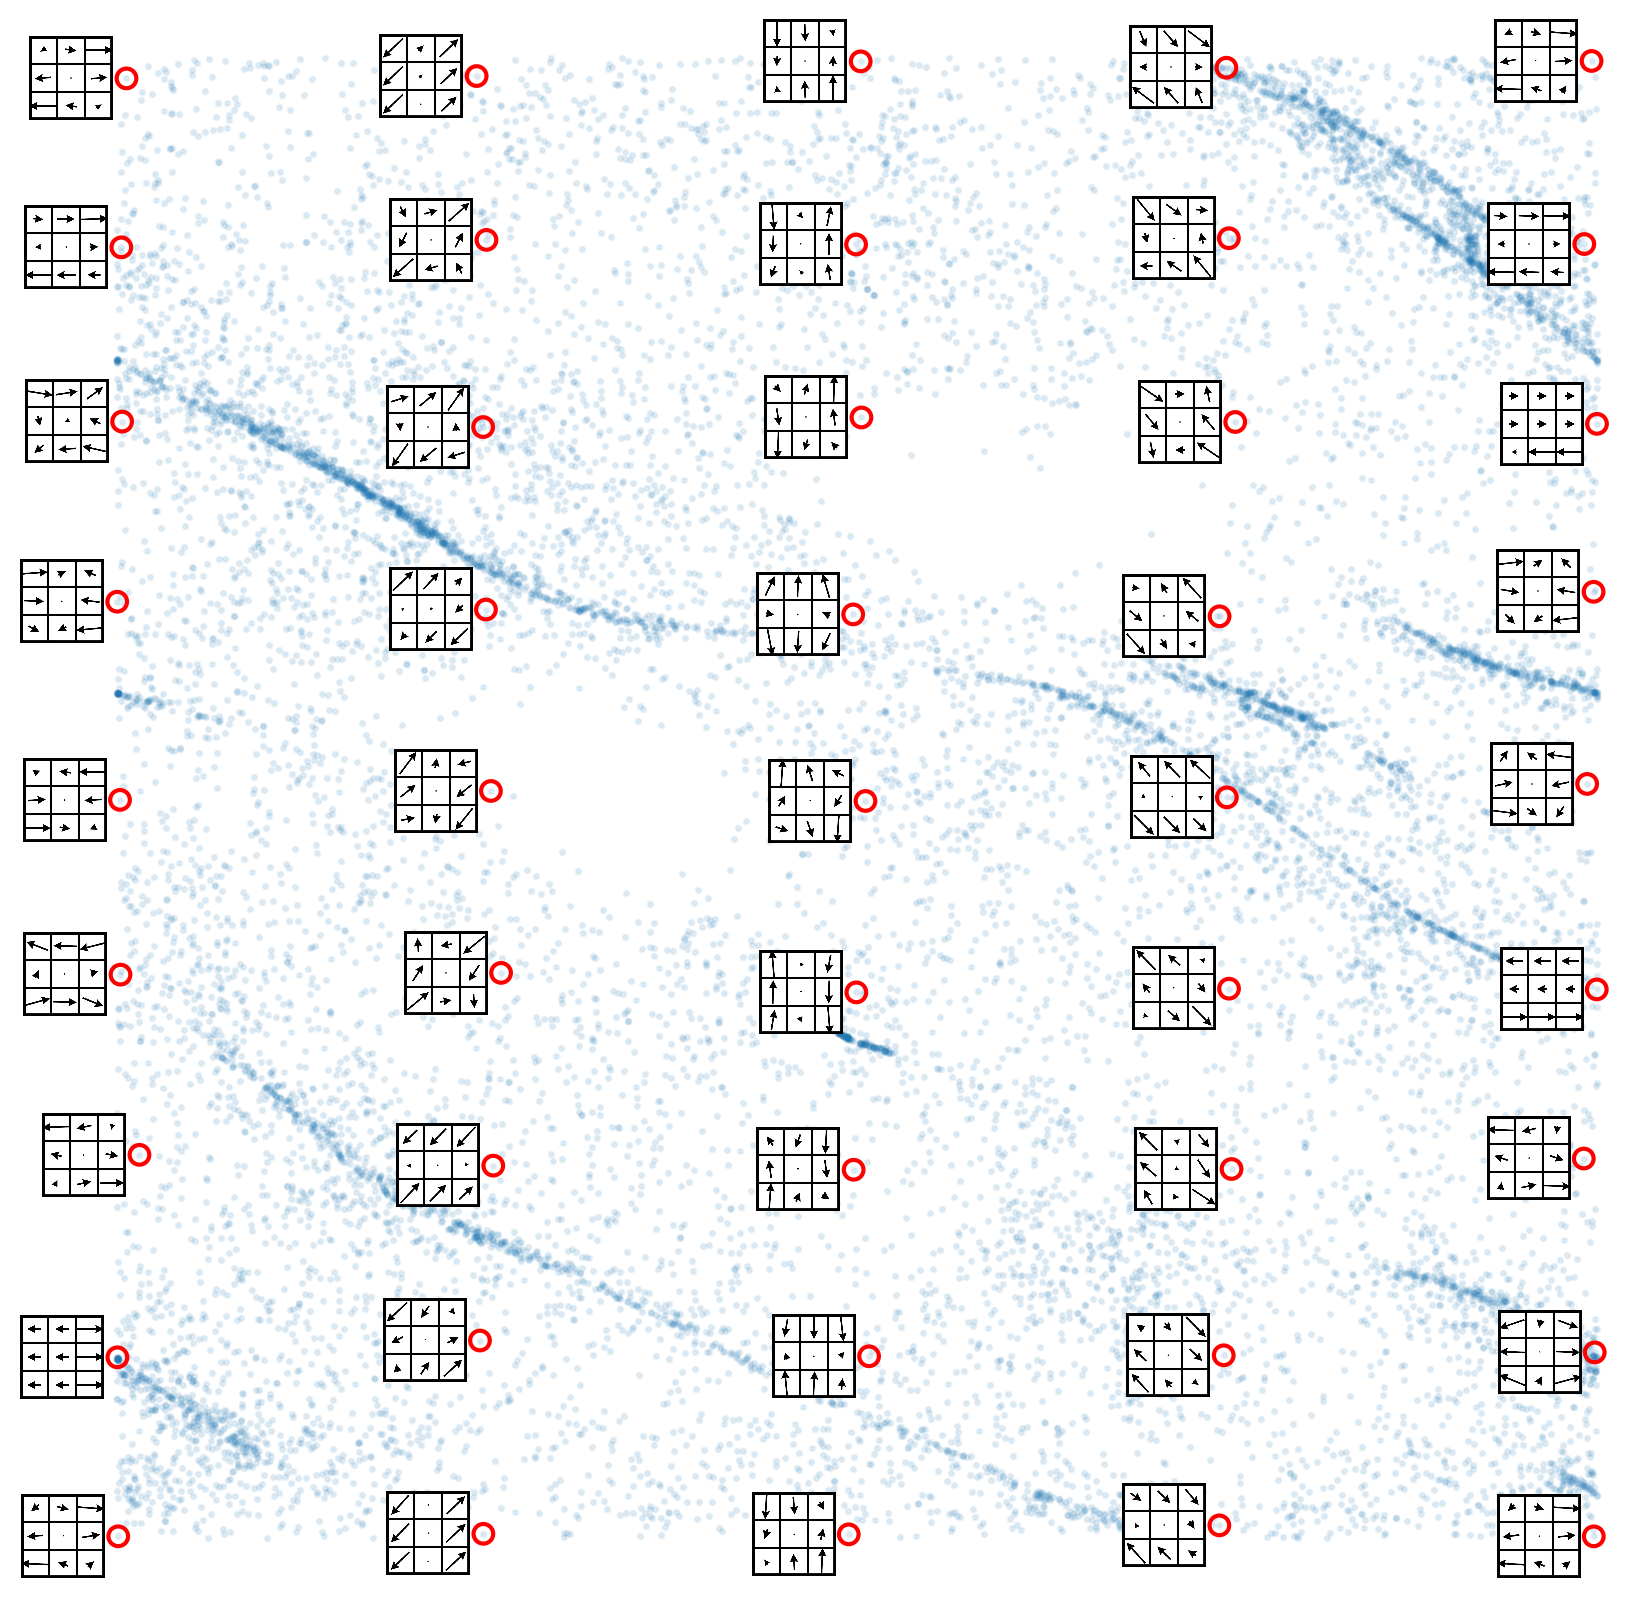

In [11]:
thresh = 0.8
high_inds = ratios > thresh
high_data = data[high_inds]
coords = np.array([predom_dirs[high_inds], fiber_angles[high_inds]]).T
print(f"{np.sum(high_inds):,} high-directionality patches")
fig, ax, selected = cb.scatter_lattice_vis(
    high_data,
    coords,
    patch_vis,
    per_row=5,
    per_col=9,
    padding=0,
)
plt.show()

In [ ]:
thresh = 0.7
low_inds = ratios < thresh
low_data = data[low_inds]
coords = np.array([predom_dirs[low_inds], fiber_angles[low_inds]]).T
print(f"{np.sum(low_inds):,} low-directionality patches")
fig, ax, selected = cb.scatter_lattice_vis(
    low_data,
    coords,
    patch_vis,
    per_row=5,
    per_col=9,
    padding=0,
)
plt.show()

Observe that every column is nearly identical: this reflects the fact that the low-directionality data is concentrated near a single circle at the center of the thickened torus structure.

## Reproduction record

Finally, save a small record of the parameters, numerical results, data source and software version used for this run. 

In [ ]:
import hashlib
import platform
import subprocess
from datetime import datetime, timezone


def top_finite_lifetimes(diagram, count=5):
    lifetimes = diagram[:, 1] - diagram[:, 0]
    finite = lifetimes[np.isfinite(lifetimes)]
    return [float(value) for value in np.sort(finite)[::-1][:count]]

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024*1024), b""):
            digest.update(block)
    return digest.hexdigest()

def git_value(*args):
    try:
        return subprocess.check_output(
            ["git", *args], cwd=ROOT, text=True, stderr=subprocess.DEVNULL
        ).strip()
    except (OSError, subprocess.CalledProcessError):
        return None

source_record = {"kind": data_source}
if artifact_path.is_file():
    source_record.update({
        "filename": artifact_path.name,
        "sha256": file_sha256(artifact_path),
    })

run_record = {
    "experiment": "extended optical-flow torus",
    "profile": profile,
    "parameters": {
        "patches_per_frame": patches_per_frame,
        "high_contrast_fraction": 0.2,
        "preprocessed_sample_cap": max_samples,
        "density_k": k,
        "density_fraction": p,
        "cover_landmarks": n_landmarks,
        "cover_overlap": overlap,
        "random_seed_for_new_sampling": random_seed,
        "historical_sampling_seed": "not recorded",
        "historical_synthetic_seed": "not recorded",
        "global_persistence_points": global_ripser_points,
        "global_persistence_real_subsampling": "ripser greedy permutation",
        "synthetic_noise_levels": list(synthetic_noise_levels),
        "synthetic_contrast_renormalized": True,
        "synthetic_noise_convention": "ambient Gaussian noise followed by per-patch contrast renormalization",
    },
    "metrics": {
        "preprocessed_patch_count": len(patch_df),
        "dense_core_patch_count": len(data),
        "high_directionality_count": int(np.sum(high_inds)),
        "low_directionality_count": int(np.sum(low_inds)),
        "class_summary": class_result.summary_text,
        "top_persistence_lifetimes": {
            f"H{dimension}": top_finite_lifetimes(diagram)
            for dimension, diagram in enumerate(diagrams)
        },
        "figure_6_panels": {
            title: {
                "diagram_counts": {
                    f"H{dimension}": len(diagram)
                    for dimension, diagram in enumerate(panel_diagrams)
                },
                "top_finite_lifetimes": {
                    f"H{dimension}": top_finite_lifetimes(diagram)
                    for dimension, diagram in enumerate(panel_diagrams)
                },
            }
            for title, panel_diagrams in global_rips.items()
        },
    },
    "outputs": {
        "global_ripsers_figure": str(global_ripsers_path.relative_to(ROOT)),
    },
    "provenance": {
        "notebook": "notebooks/01_extended_torus.ipynb",
        "data_source": source_record,
        "repository_commit": git_value("rev-parse", "HEAD"),
        "repository_had_uncommitted_changes": bool(git_value("status", "--porcelain")),
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "python_version": platform.python_version(),
        "numpy_version": np.__version__,
        "circle_bundles_version": getattr(cb, "__version__", "unknown"),
    },
}

record_path = ROOT / "results" / profile / "extended_torus_run.json"
record_path.parent.mkdir(parents=True, exist_ok=True)
record_path.write_text(json.dumps(run_record, indent=2, sort_keys=True) + "\n")
print(f"Wrote reproduction record to {record_path}")
run_record